# Simple feature importance comparison

This notebook answers three basic questions:

1. Which features matter most to the saved draft classifier and minutes regressor?
2. How do their top features differ?
3. What happens when each model is retrained with only its own top features or the other model's top transferable features?

The experiment keeps the existing XGBoost settings, chronological 2020-2022 test period, preprocessing, and project metrics. TOP_N controls the subset size. Built-in XGBoost importance describes how the fitted model used a feature; it is not a causal effect.

In [1]:
from copy import deepcopy
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from pandas.api.types import is_numeric_dtype


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT / "src"))

import classifier_workflow as classifier
import train_model as regressor


TOP_N = 10
CLASSIFIER_CONFIG_PATH = REPO_ROOT / "configs/xgboost_draft_classifier_advanced_search_best.json"
CLASSIFIER_MODEL_PATH = REPO_ROOT / "models/xgboost_draft_classifier_advanced_search.joblib"

# These frozen settings match the fitted search artifact below.
REGRESSOR_CONFIG_PATH = REPO_ROOT / "configs/xgboost_minutes_advanced_best.json"
REGRESSOR_MODEL_PATH = REPO_ROOT / "models/xgboost_minutes_advanced_search.joblib"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)

In [2]:
classifier_config = classifier.load_config(CLASSIFIER_CONFIG_PATH)
regressor_config = regressor.load_config(REGRESSOR_CONFIG_PATH)

classifier_artifact = joblib.load(CLASSIFIER_MODEL_PATH)
classifier_model = classifier_artifact["estimator"]
regressor_model = joblib.load(REGRESSOR_MODEL_PATH)

classifier_features = classifier_config["numerical_features"] + classifier_config["categorical_features"]
regressor_features = regressor.feature_columns(regressor_config)
assert classifier_artifact["feature_columns"] == classifier_features
assert all(
    classifier_model.named_steps["model"].get_params()[name] == value
    for name, value in classifier_config["model"]["hyperparameters"].items()
), "Classifier config and saved model do not match."
assert all(
    regressor_model.named_steps["model"].get_params()[name] == value
    for name, value in regressor_config["model"]["hyperparameters"].items()
), "Regressor config and saved model do not match."

classifier_data = classifier.prepare_data(
    classifier.load_data(classifier.resolve(classifier_config["data_path"])),
    classifier_config,
)
classifier_splits = classifier.chronological_splits(classifier_data, classifier_config["split"])

regressor_data = regressor.prepare_data(
    regressor.load_data(regressor.resolve_path(regressor_config["data_path"])),
    regressor_config,
)
regressor_splits = regressor.split_data(regressor_data, regressor_config["split"])

model_summary = pd.DataFrame(
    [
        {
            "model": "Draft classifier",
            "target": classifier_config["target"],
            "features": len(classifier_features),
            "train rows": len(classifier_splits["train"]),
            "validation rows": len(classifier_splits["validation"]),
            "test rows": len(classifier_splits["test"]),
        },
        {
            "model": "Minutes regressor",
            "target": regressor_config["target"],
            "features": len(regressor_features),
            "train rows": len(regressor_splits["train"]),
            "validation rows": len(regressor_splits["validation"]),
            "test rows": len(regressor_splits["test"]),
        },
    ]
)
display(model_summary)

,model,target,features,train rows,validation rows,test rows
0,Draft classifier,drafted,107,510,146,202
1,Minutes regressor,nba_min_3y,48,540,120,178


## Feature importance

The classifier one-hot encodes position. The helper below sums any encoded columns back to their original raw feature so both models can be compared at the same level.

In [3]:
def raw_feature_importance(model, raw_features: list[str]) -> pd.DataFrame:
    preprocessor = model.named_steps["preprocessor"]
    estimator = model.named_steps["model"]
    transformed_names = preprocessor.get_feature_names_out()
    values = np.asarray(estimator.feature_importances_, dtype=float)
    if len(transformed_names) != len(values):
        raise ValueError("Feature names and importance values do not align.")

    def find_raw_feature(transformed_name: str) -> str:
        name = transformed_name.split("__", maxsplit=1)[-1]
        matches = [
            feature
            for feature in raw_features
            if name == feature or name.startswith(f"{feature}_")
        ]
        if not matches:
            raise ValueError(f"Could not map transformed feature: {transformed_name}")
        return max(matches, key=len)

    importance = pd.DataFrame(
        {
            "feature": [find_raw_feature(name) for name in transformed_names],
            "importance": values,
        }
    )
    importance = (
        importance.groupby("feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    importance.insert(0, "rank", np.arange(1, len(importance) + 1))
    importance["importance_pct"] = 100 * importance["importance"] / importance["importance"].sum()
    return importance


classifier_importance = raw_feature_importance(classifier_model, classifier_features)
regressor_importance = raw_feature_importance(regressor_model, regressor_features)

,rank,classifier feature,classifier importance (%),minutes feature,minutes importance (%)
0,1,college_age_adjusted_stocks,2.75,overall_pick,20.84
1,2,college_age_adjusted_scoring,2.38,draft_pick_log,19.55
2,3,college_career_playmaking_margin_per_40,2.21,draft_pick_sqrt,9.36
3,4,college_last_production_index,2.18,college_last_playmaking_margin_per_40,8.18
4,5,combine_drill_standing_vertical_leap,2.10,college_last_assist_turnover_ratio,6.52
5,6,college_career_three_pct,2.10,age_on_draft_year_july1_missing,6.38
6,7,college_last_stocks_per_40_advanced,2.00,draft_pick_squared,4.76
7,8,combine_drill_max_vertical_leap,2.00,draft_pick_inverse,2.63
8,9,college_last_minutes,1.97,college_career_ft_pct_shrunk,2.43
9,10,college_career_stocks_per_40_advanced,1.91,college_last_rebounds_per_40,2.34


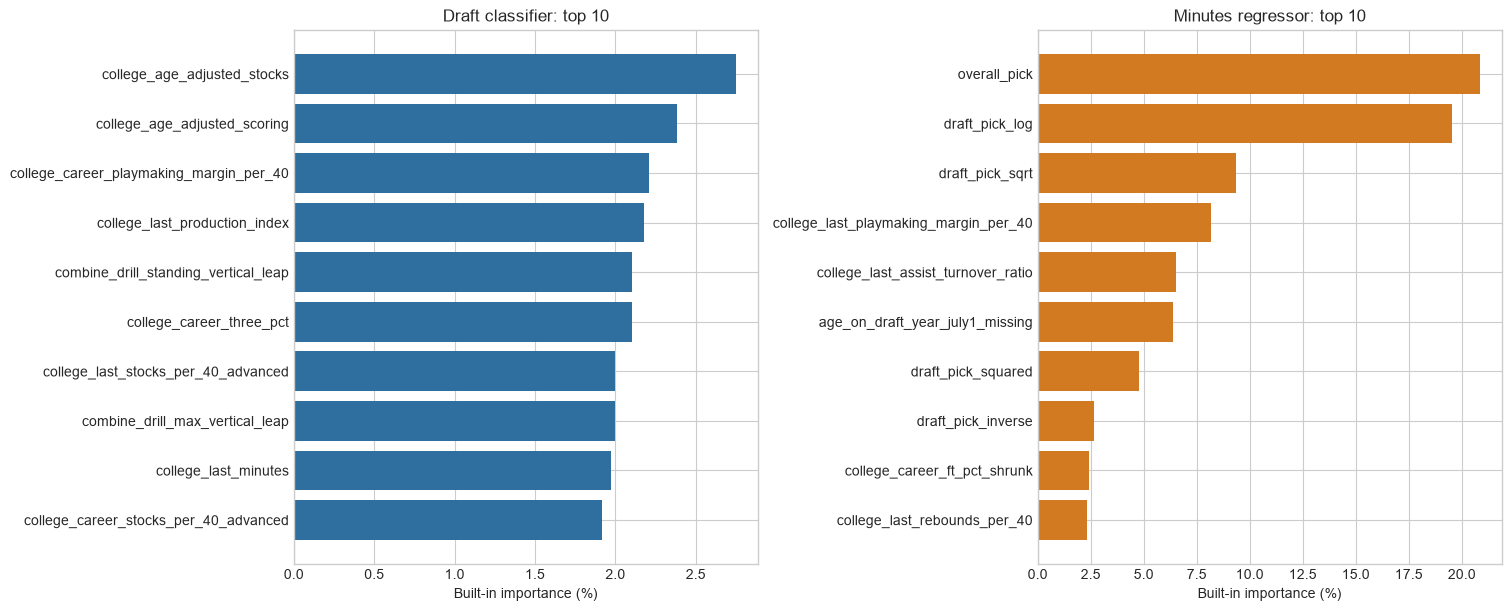

In [4]:
top_comparison = pd.DataFrame(
    {
        "rank": np.arange(1, TOP_N + 1),
        "classifier feature": classifier_importance.head(TOP_N)["feature"].to_numpy(),
        "classifier importance (%)": classifier_importance.head(TOP_N)["importance_pct"].to_numpy(),
        "minutes feature": regressor_importance.head(TOP_N)["feature"].to_numpy(),
        "minutes importance (%)": regressor_importance.head(TOP_N)["importance_pct"].to_numpy(),
    }
)
display(top_comparison.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
for ax, importance, title, color in [
    (axes[0], classifier_importance, "Draft classifier", "#2f6f9f"),
    (axes[1], regressor_importance, "Minutes regressor", "#d17a22"),
]:
    plot_data = importance.head(TOP_N).sort_values("importance_pct")
    ax.barh(plot_data["feature"], plot_data["importance_pct"], color=color)
    ax.set_title(f"{title}: top {TOP_N}")
    ax.set_xlabel("Built-in importance (%)")
    ax.set_ylabel("")
plt.show()

In [5]:
configured_overlap = set(classifier_features) & set(regressor_features)
top_overlap = set(classifier_importance.head(TOP_N)["feature"]) & set(regressor_importance.head(TOP_N)["feature"])

print(f"Configured features shared by both models: {len(configured_overlap)}")
print(f"Direct overlap between their top {TOP_N}: {len(top_overlap)}")
print("Shared top features:", ", ".join(sorted(top_overlap)) if top_overlap else "none")
print("Classifier top three:", ", ".join(classifier_importance.head(3)["feature"]))
print("Minutes top three:", ", ".join(regressor_importance.head(3)["feature"]))


def top_transferable_features(
    importance: pd.DataFrame,
    target_data: pd.DataFrame,
    n: int,
    forbidden=None,
) -> tuple[list[str], list[str]]:
    selected = []
    skipped = []
    forbidden = forbidden or (lambda feature: False)
    for feature in importance["feature"]:
        if feature not in target_data.columns or forbidden(feature):
            skipped.append(feature)
            continue
        selected.append(feature)
        if len(selected) == n:
            break
    if len(selected) < n:
        raise ValueError(f"Only {len(selected)} transferable features were available.")
    return selected, skipped


def unsafe_for_classifier(feature: str) -> bool:
    return (
        classifier.feature_leakage_reason(feature) is not None
        or feature.startswith("draft_pick_")
    )


classifier_own_top = classifier_importance.head(TOP_N)["feature"].tolist()
regressor_own_top = regressor_importance.head(TOP_N)["feature"].tolist()
classifier_from_regressor, skipped_for_classifier = top_transferable_features(
    regressor_importance,
    classifier_data,
    TOP_N,
    forbidden=unsafe_for_classifier,
)
regressor_from_classifier, skipped_for_regressor = top_transferable_features(
    classifier_importance,
    regressor_data,
    TOP_N,
)

feature_sets = pd.DataFrame(
    [
        {"model": "Draft classifier", "subset": "Own top features", "features": ", ".join(classifier_own_top)},
        {"model": "Draft classifier", "subset": "Minutes model top transferable", "features": ", ".join(classifier_from_regressor)},
        {"model": "Minutes regressor", "subset": "Own top features", "features": ", ".join(regressor_own_top)},
        {"model": "Minutes regressor", "subset": "Classifier top transferable", "features": ", ".join(regressor_from_classifier)},
    ]
)
display(feature_sets)
print("Skipped before finding 10 safe classifier inputs:", ", ".join(skipped_for_classifier))
print("Skipped before finding 10 available minutes inputs:", ", ".join(skipped_for_regressor) or "none")

Configured features shared by both models: 19
Direct overlap between their top 10: 0
Shared top features: none
Classifier top three: college_age_adjusted_stocks, college_age_adjusted_scoring, college_career_playmaking_margin_per_40
Minutes top three: overall_pick, draft_pick_log, draft_pick_sqrt


,model,subset,features
0,Draft classifier,Own top features,"college_age_adjusted_stocks, college_age_adjusted_scoring, college_career_playmaking_margin_per_40, college_last_pro..."
1,Draft classifier,Minutes model top transferable,"college_last_playmaking_margin_per_40, college_last_assist_turnover_ratio, college_career_ft_pct_shrunk, college_las..."
2,Minutes regressor,Own top features,"overall_pick, draft_pick_log, draft_pick_sqrt, college_last_playmaking_margin_per_40, college_last_assist_turnover_r..."
3,Minutes regressor,Classifier top transferable,"college_age_adjusted_stocks, college_age_adjusted_scoring, college_career_playmaking_margin_per_40, college_last_pro..."


Skipped before finding 10 safe classifier inputs: overall_pick, draft_pick_log, draft_pick_sqrt, age_on_draft_year_july1_missing, draft_pick_squared, draft_pick_inverse, college_last_vs_career_three_pct, college_last_vs_career_steals_per_40, college_last_vs_career_blocks_per_40, age_on_draft_year_july1
Skipped before finding 10 available minutes inputs: none


## Retrain with smaller feature sets

The loaded full models are the baselines. Each subset model is fitted with the same frozen hyperparameters and train-plus-validation refit used by its baseline. The classifier also keeps the same calibration procedure and annual decision rule. Transferable means present in the target model's processed table and safe for that target; it does not require membership in the target model's original configured feature list. No tuning is repeated, and all rows are evaluated on the same 2020-2022 holdout. For the classifier, average precision and ROC-AUC are the holdout ranking comparisons; balanced accuracy and F1 use the previously repaired annual operating rule and are included only as familiar context.

In [6]:
def config_for_features(base_config: dict, features: list[str], data: pd.DataFrame) -> dict:
    config = deepcopy(base_config)
    missing = sorted(set(features) - set(data.columns))
    if missing:
        raise ValueError(f"Features missing from the target dataset: {missing}")

    original_categorical = set(base_config["categorical_features"])
    config["categorical_features"] = [
        feature
        for feature in features
        if feature in original_categorical or not is_numeric_dtype(data[feature])
    ]
    categorical = set(config["categorical_features"])
    config["numerical_features"] = [feature for feature in features if feature not in categorical]
    return config


def fit_classifier_subset(features: list[str]):
    config = config_for_features(classifier_config, features, classifier_data)
    model, calibrator, decision_rule, _ = classifier.fit_configured_classifier(
        config,
        classifier_splits,
    )
    return model, calibrator, decision_rule


def classifier_test_metrics(model, calibrator, decision_rule, features: list[str]) -> dict:
    return classifier.evaluate(
        model,
        classifier_splits["test"],
        features,
        classifier_config["target"],
        calibrator=calibrator,
        decision_rule=decision_rule,
        year_column=classifier_config["split"]["column"],
    )


def fit_regressor_subset(features: list[str]):
    config = config_for_features(regressor_config, features, regressor_data)
    model = regressor.make_pipeline(config)
    fit_data = regressor_splits["train"]
    if config.get("refit_on_train_validation", False):
        fit_data = pd.concat([regressor_splits["train"], regressor_splits["validation"]])
    model.fit(fit_data[features], fit_data[config["target"]])
    return model


def regressor_test_metrics(model, features: list[str]) -> dict:
    return regressor.evaluate(
        model,
        {"test": regressor_splits["test"]},
        features,
        regressor_config["target"],
    )["test"]

In [7]:
classification_runs = [
    (
        "All configured features (saved model)",
        classifier_model,
        classifier_artifact["probability_calibrator"],
        classifier_artifact["decision_rule"],
        classifier_features,
    )
]

for label, features in [
    (f"Own top {TOP_N}", classifier_own_top),
    (f"Minutes top {TOP_N} transferable", classifier_from_regressor),
]:
    model, calibrator, decision_rule = fit_classifier_subset(features)
    classification_runs.append((label, model, calibrator, decision_rule, features))

classification_results = []
for label, model, calibrator, decision_rule, features in classification_runs:
    metrics = classifier_test_metrics(model, calibrator, decision_rule, features)
    classification_results.append(
        {
            "feature set": label,
            "features": len(features),
            "average precision": metrics["average_precision"],
            "ROC-AUC": metrics["roc_auc"],
            "balanced accuracy": metrics["balanced_accuracy"],
            "F1": metrics["f1"],
        }
    )

classification_results = pd.DataFrame(classification_results)
display(classification_results.round(3))

,feature set,features,average precision,ROC-AUC,balanced accuracy,F1
0,All configured features (saved model),107,0.825,0.751,0.657,0.741
1,Own top 10,10,0.769,0.684,0.636,0.725
2,Minutes top 10 transferable,10,0.742,0.660,0.626,0.717


In [8]:
regression_runs = [
    ("All configured features (saved model)", regressor_model, regressor_features),
]

for label, features in [
    (f"Own top {TOP_N}", regressor_own_top),
    (f"Classifier top {TOP_N} transferable", regressor_from_classifier),
]:
    regression_runs.append((label, fit_regressor_subset(features), features))

regression_results = []
for label, model, features in regression_runs:
    metrics = regressor_test_metrics(model, features)
    regression_results.append(
        {
            "feature set": label,
            "features": len(features),
            "RMSE": metrics["rmse"],
            "R-squared": metrics["r2"],
        }
    )

regression_results = pd.DataFrame(regression_results)
display(regression_results.round(3))

,feature set,features,RMSE,R-squared
0,All configured features (saved model),48,1568.183,0.482
1,Own top 10,10,1559.774,0.487
2,Classifier top 10 transferable,10,2227.684,-0.045


## Basic takeaway

For the classifier, higher average precision, ROC-AUC, balanced accuracy, and F1 are better. For the minutes model, lower RMSE and higher R-squared are better. The short summary below reports the highest average precision and lowest RMSE in this descriptive holdout comparison; it should not be used to retune or select a final model without a future evaluation cohort.

In [9]:
highest_classifier_row = classification_results.loc[classification_results["average precision"].idxmax()]
lowest_regressor_row = regression_results.loc[regression_results["RMSE"].idxmin()]

print(
    f"Highest classifier average precision in this comparison: {highest_classifier_row['feature set']} "
    f"({highest_classifier_row['average precision']:.3f})."
)
print(
    f"Lowest minutes RMSE in this comparison: {lowest_regressor_row['feature set']} "
    f"({lowest_regressor_row['RMSE']:.1f})."
)
print(
    "The minutes model is led by draft position, while the draft classifier is led by "
    "college production/age combinations and Combine measurements. The transfer rows show "
    "whether those priorities remain useful for the other target."
)

Highest classifier average precision in this comparison: All configured features (saved model) (0.825).
Lowest minutes RMSE in this comparison: Own top 10 (1559.8).
The minutes model is led by draft position, while the draft classifier is led by college production/age combinations and Combine measurements. The transfer rows show whether those priorities remain useful for the other target.
